<a href="https://colab.research.google.com/github/Sneha-code01/ML/blob/main/batterypredict_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# current inida = 0.71, renewable = 0.05, 2035 = 0.35 _CAE
# manufacture = 65kwh electricity required and used 20 for 100%recycle credit
import pandas as pd
from itertools import product

chemistries = [
    'LFP','LTO','LMO','LCO','NCA',
    'NMC111','NMC532','NMC622',
    'NMC811','NMC442'
]

scenarios = [
    'Current_India_Grid',
    'Renewable_India',
    'India_2035'
]

recycling_rates = [0,20,30,40,50,60,70,80,90,100]

energy_density = {
    'LFP':140,
    'LTO':80,
    'LMO':150,
    'LCO':190,
    'NCA':260,
    'NMC111':230,
    'NMC442':210,
    'NMC532':220,
    'NMC622':260,
    'NMC811':280,
}
cycle_life = {
'LFP':4000,
'LTO':10000,
'LMO':1000,
'LCO':800,
'NCA':1500,
'NMC111':2000,
'NMC442':2200,
'NMC532':2500,
'NMC622':3000,
'NMC811':3500,
}
#co2 equivalent calculation
material_emission = {
    'LFP':30,
    'LTO':33,
    'LMO':34,
    'LCO':48,
    'NCA':52,
    'NMC111':43,
    'NMC442':45,
    'NMC532':47,
    'NMC622':50,
    'NMC811':54,
}

cell_production = {
    'LFP':13,
    'LTO':14,
    'LMO':14,
    'LCO':15,
    'NCA':17,
    'NMC111':15,
    'NMC442':15,
    'NMC532':16,
    'NMC622':17,
    'NMC811':18,
}

grid_factor = {
    'Current_India_Grid':0.71,
    'Renewable_India':0.05,
    'India_2035':0.35
}

data = list(product(
    chemistries,
    scenarios,
    recycling_rates
))

df = pd.DataFrame(
    data,
    columns=[
        'Chemistry',
        'Scenario',
        'Recycling_Rate'
    ]
)

df['Energy_Density_kWh'] = (
    df['Chemistry']
    .map(energy_density)
)
df['Cycle_Life'] = (
    df['Chemistry']
    .map(cycle_life)
)

df['Material_Emission'] = (
    df['Chemistry']
    .map(material_emission)
)

df['Cell_Production_Emission'] = (
    df['Chemistry']
    .map(cell_production)
)

df['Base_Emission'] = (
    df['Material_Emission']
    +
    df['Cell_Production_Emission']
)

df['Grid_Factor'] = (
    df['Scenario']
    .map(grid_factor)
)

# Manufacturing electricity demand
manufacturing_energy = 65

df['Manufacturing_Emission'] = (
    manufacturing_energy
    *
    df['Grid_Factor']
)

# Recycling credit
df['Recycling_Credit'] = (
    20
    *
    df['Recycling_Rate']
    /100
)
#unit co2-eq-gwp100
# Final target column of co2 equivalent
df['CO2-eq'] = (
    df['Base_Emission']
    +
    df['Manufacturing_Emission']
    -
    df['Recycling_Credit']
)


# Acidification factors for electricity scenarios
#unit is kg_so2_eq
acid_grid_factor = {
    'Current_India_Grid':0.0045,
    'India_2035':0.0020,
    'Renewable_India':0.0005
}

# Base acidification values (kg SO2-eq/kWh battery)
base_acidification = {
    'LFP':0.16,
    'LTO':0.18,
    'LMO':0.25,
    'LCO':0.42,
    'NCA':0.48,
    'NMC111':0.28,
    'NMC442':0.31,
    'NMC532':0.34,
    'NMC622':0.40,
    'NMC811':0.43,
}
# Chemistry-specific recycling credits for acidification
acid_recycling_credit = {
    'LFP': 0.04,
    'LTO': 0.04,
    'LMO': 0.05,
    'LCO': 0.10,
    'NCA': 0.12,
    'NMC111': 0.08,
    'NMC442': 0.09,
    'NMC532': 0.10,
    'NMC622': 0.11,
    'NMC811': 0.12,
}
# Adding base acidification column
df['Base_Acidification'] = df['Chemistry'].map(base_acidification)

df['Acid_Grid_Factor'] = df['Scenario'].map(acid_grid_factor)

manufacturing_energy = 65

df['Manufacturing_Acidification'] = (
    manufacturing_energy * df['Acid_Grid_Factor']
)

df['Acidification_Credit'] = (
    df['Chemistry'].map(acid_recycling_credit)
    * df['Recycling_Rate']
    / 100
)

df['Acidification-eq'] = (
    df['Base_Acidification']
    + df['Manufacturing_Acidification']
    - df['Acidification_Credit']
)
#Human Toxicity Potential (HTP) Nickel mining, Cobalt mining, Lithium production, Graphite processing
#taken from the research papers and greet it sthe value due to the material it self
base_htp = {
    'LFP':8,
    'LTO':9,
    'LMO':11,
    'LCO':28,
    'NCA':32,
    'NMC111':22,
    'NMC442':24,
    'NMC532':26,
    'NMC622':29,
    'NMC811':34
}
#kg 1,4-DCB-eq/kWh is unit of htp
#because electricity contributes much less to HTP than material extraction.(65*elec source htp contri)
htp_grid_factor = {
    'Current_India_Grid':0.035,
    'India_2035':0.020,
    'Renewable_India':0.008
}
#High Ni/Co chemistries gain more from recycling. ie the htp is very less in such cases
recycling_credit_htp = {
    'LFP':4,
    'LTO':4,
    'LMO':5,
    'LCO':12,
    'NCA':14,
    'NMC111':10,
    'NMC442':11,
    'NMC532':12,
    'NMC622':13,
    'NMC811':14
}
#htp column addition
df['Base_HTP'] = df['Chemistry'].map(base_htp)

df['HTP_Grid_Factor'] = df['Scenario'].map(htp_grid_factor)

df['Manufacturing_HTP'] = (
    65 * df['HTP_Grid_Factor']
)

df['HTP_Recycling_Credit'] = (
    df['Chemistry'].map(recycling_credit_htp)
    * df['Recycling_Rate']
    / 100
)

df['Human_Toxicity'] = (
    df['Base_HTP']
    + df['Manufacturing_HTP']
    - df['HTP_Recycling_Credit']
)
#papers by Majeau-Bettez, Ellingsen, and Ciez & Whitacre and data from niti ayoag and greet
print(df[['Chemistry',
        'Scenario',
        'Recycling_Rate',
        'CO2-eq',
        'Energy_Density_kWh',
          'Cycle_Life',
        'Acidification-eq',
          'Human_Toxicity']])

df.to_csv(
    'battery_dataset.csv',
    index=False
)


    Chemistry            Scenario  Recycling_Rate  CO2-eq  Energy_Density_kWh  \
0         LFP  Current_India_Grid               0   89.15                 140   
1         LFP  Current_India_Grid              20   85.15                 140   
2         LFP  Current_India_Grid              30   83.15                 140   
3         LFP  Current_India_Grid              40   81.15                 140   
4         LFP  Current_India_Grid              50   79.15                 140   
..        ...                 ...             ...     ...                 ...   
295    NMC442          India_2035              60   70.75                 210   
296    NMC442          India_2035              70   68.75                 210   
297    NMC442          India_2035              80   66.75                 210   
298    NMC442          India_2035              90   64.75                 210   
299    NMC442          India_2035             100   62.75                 210   

     Cycle_Life  Acidificat

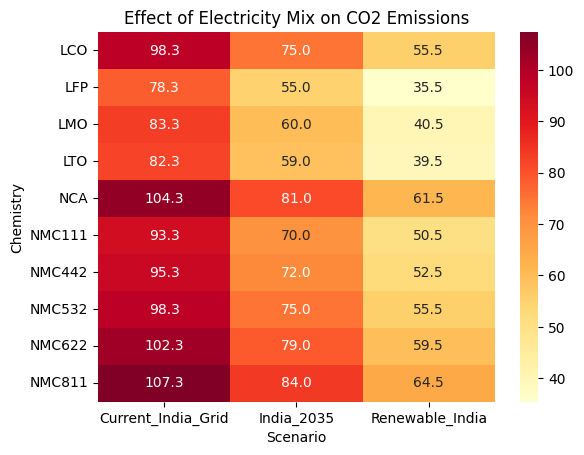

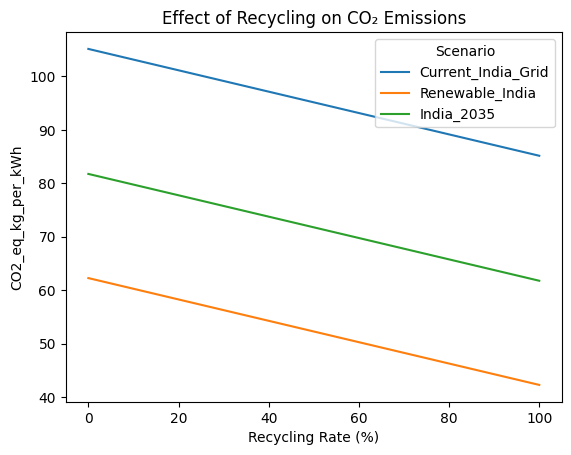

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
pivot = df.pivot_table(
    values='CO2-eq',
    index='Chemistry',
    columns='Scenario',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlOrRd',
    fmt='.1f'
)

plt.title('Effect of Electricity Mix on CO2 Emissions')
plt.show()
plt.figure()
sns.lineplot(
    data=df,
    x='Recycling_Rate',
    y='CO2-eq',
    hue='Scenario',
    errorbar=None
)

plt.xlabel('Recycling Rate (%)')
plt.ylabel('CO2_eq_kg_per_kWh')
plt.title('Effect of Recycling on CO₂ Emissions')
plt.show()


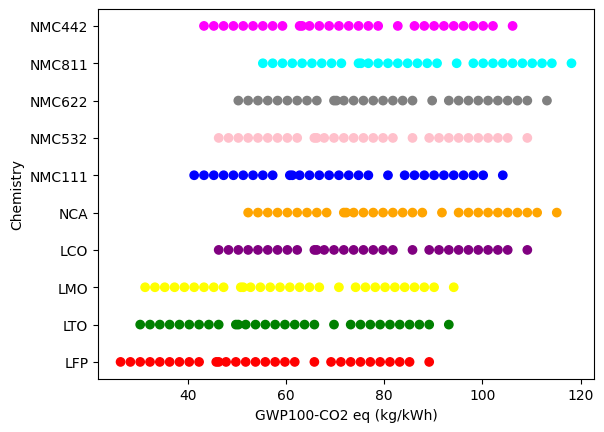

In [30]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
     'NMC442':'magenta',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',
    'NMC442':'magenta'
}

plt.scatter(
    df['CO2-eq'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('GWP100-CO2 eq (kg/kWh)')
plt.ylabel('Chemistry')
plt.show()

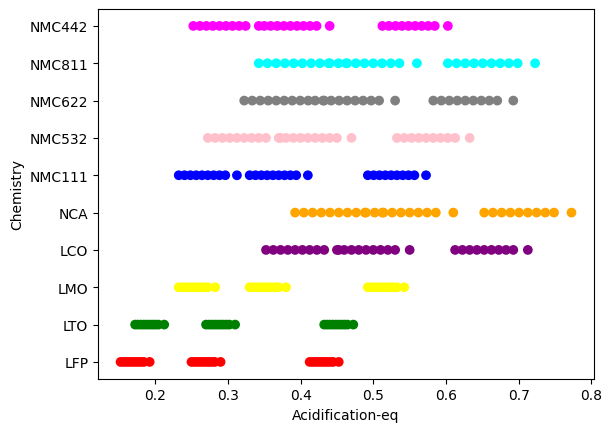

In [33]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC442':'magenta',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',

}
plt.scatter(
    df['Acidification-eq'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('Acidification-eq')
plt.ylabel('Chemistry')
plt.show()

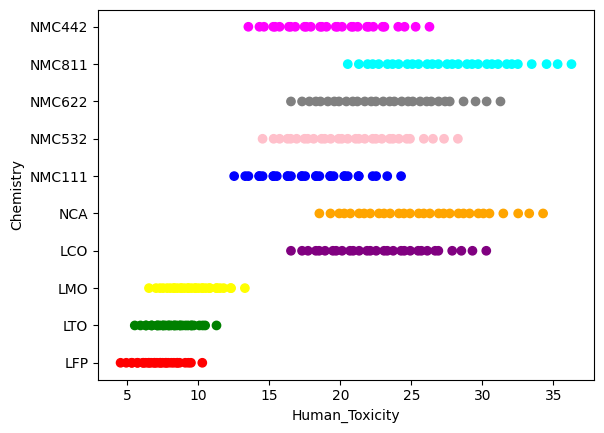

In [34]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC442':'magenta',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',

}
plt.scatter(
    df['Human_Toxicity'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('Human_Toxicity')
plt.ylabel('Chemistry')
plt.show()

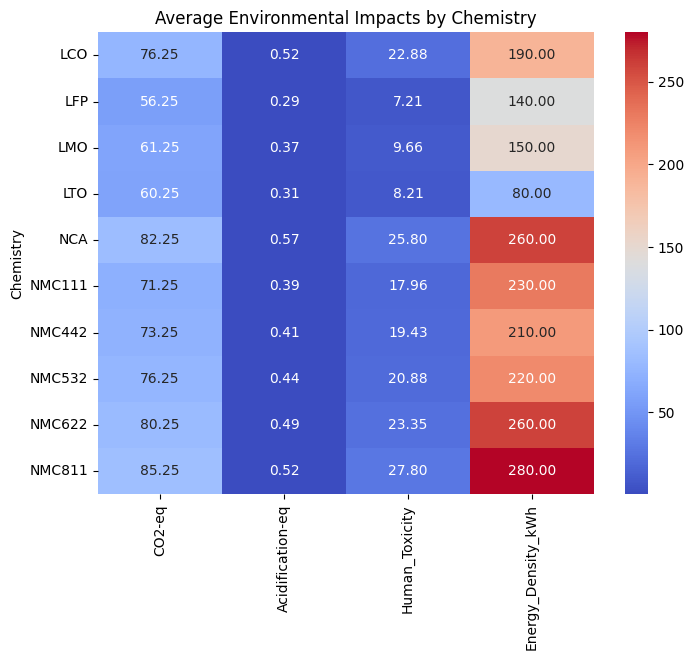

In [35]:
#plotting co2,acidification and htp graph together
import seaborn as sns
import matplotlib.pyplot as plt

avg_df = df.groupby('Chemistry')[
    [
        'CO2-eq',
        'Acidification-eq',
        'Human_Toxicity',
        'Energy_Density_kWh',
    ]
].mean()

plt.figure(figsize=(8,6))

sns.heatmap(
    avg_df,
    annot=True,
    cmap = 'coolwarm',
    fmt='.2f'
)

plt.title('Average Environmental Impacts by Chemistry')
plt.show()

In [36]:
#mathematical analysis from the data
df.describe()

,Recycling_Rate,Energy_Density_kWh,Cycle_Life,Material_Emission,Cell_Production_Emission,Base_Emission,Grid_Factor,Manufacturing_Emission,Recycling_Credit,CO2-eq,Base_Acidification,Acid_Grid_Factor,Manufacturing_Acidification,Acidification_Credit,Acidification-eq,Base_HTP,HTP_Grid_Factor,Manufacturing_HTP,HTP_Recycling_Credit,Human_Toxicity
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,54.000000,202.000000,3050.000000,43.600000,15.400000,59.00000,0.370000,24.050000,10.800000,72.250000,0.325000,0.002333,0.151667,0.045900,0.430767,22.300000,0.021000,1.365000,5.346000,18.319000
std,30.448158,59.731842,2518.261066,8.028378,1.499164,9.43912,0.270266,17.567262,6.089632,20.851602,0.103153,0.001653,0.107424,0.031793,0.141459,9.148167,0.011064,0.719148,3.840083,7.823693
min,0.000000,80.000000,800.000000,30.000000,13.000000,43.00000,0.050000,3.250000,0.000000,26.250000,0.160000,0.000500,0.032500,0.000000,0.152500,8.000000,0.008000,0.520000,0.000000,4.520000
25%,30.000000,150.000000,1500.000000,34.000000,14.000000,48.00000,0.050000,3.250000,6.000000,56.250000,0.250000,0.000500,0.032500,0.021500,0.324000,11.000000,0.008000,0.520000,2.400000,10.275000
50%,55.000000,215.000000,2350.000000,46.000000,15.000000,61.50000,0.350000,22.750000,11.000000,71.750000,0.325000,0.002000,0.130000,0.040000,0.429250,25.000000,0.020000,1.300000,4.300000,19.310000
75%,80.000000,260.000000,3500.000000,50.000000,17.000000,67.00000,0.710000,46.150000,16.000000,88.300000,0.420000,0.004500,0.292500,0.070500,0.530000,29.000000,0.035000,2.275000,8.400000,24.158750
max,100.000000,280.000000,10000.000000,54.000000,18.000000,72.00000,0.710000,46.150000,20.000000,118.150000,0.480000,0.004500,0.292500,0.120000,0.772500,34.000000,0.035000,2.275000,14.000000,36.275000


Text(0.5, 0.5, 'GHG')

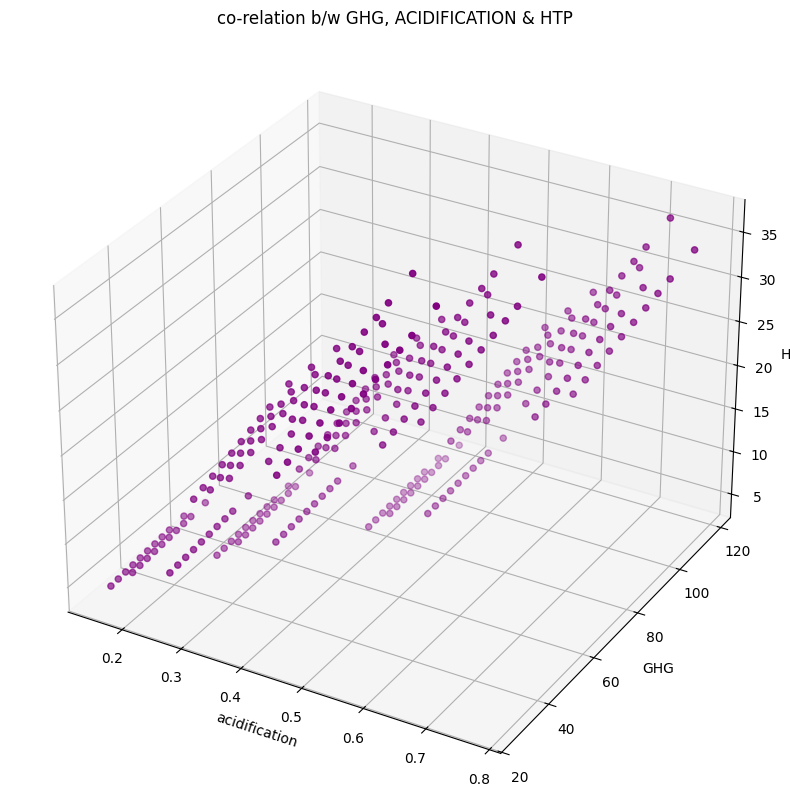

In [37]:
#3d plot to check relation b/w co2 nox/sox and htp
fig = plt.figure(figsize=(16,10))
ax= plt.subplot(projection='3d')
ax.scatter3D(df['Acidification-eq'],df['CO2-eq'],df['Human_Toxicity'],c='purple')
ax.set_title('co-relation b/w GHG, ACIDIFICATION & HTP')
ax.set_zlabel('HTP')
ax.set_xlabel('acidification')
ax.set_ylabel('GHG')

    Chemistry    CO2-eq  Acidification-eq  Human_Toxicity  Energy_Density_kWh  \
0         LFP  0.684440          0.483871        0.181231                0.30   
1         LFP  0.640914          0.470968        0.156038                0.30   
2         LFP  0.619151          0.464516        0.143442                0.30   
3         LFP  0.597388          0.458065        0.130846                0.30   
4         LFP  0.575626          0.451613        0.118249                0.30   
..        ...       ...               ...             ...                 ...   
295    NMC442  0.484222          0.376613        0.446544                0.65   
296    NMC442  0.462459          0.362097        0.411904                0.65   
297    NMC442  0.440696          0.347581        0.377263                0.65   
298    NMC442  0.418934          0.333065        0.342623                0.65   
299    NMC442  0.397171          0.318548        0.307983                0.65   

     Cycle_norm  
0      0.

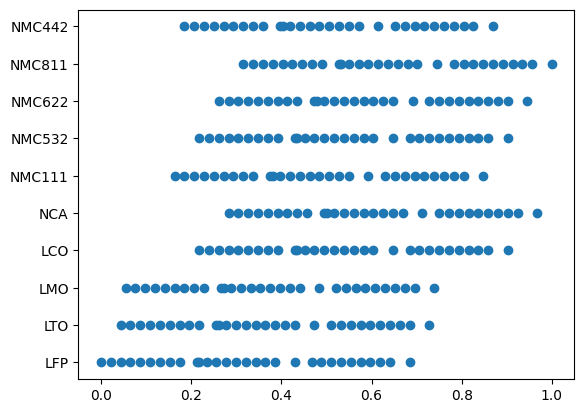

In [38]:
#EDA done to normalize the major colums and bring the value in range of 0-1 and perform better ml training'
from sklearn.preprocessing import MinMaxScaler
import numpy as np
scaler = MinMaxScaler()
cols = [
    'CO2-eq',
    'Acidification-eq',
    'Human_Toxicity',
    'Energy_Density_kWh',
]
df[cols] = scaler.fit_transform(df[cols])
df['Cycle_log'] = np.log10(df['Cycle_Life'])
df[['Cycle_norm']] = scaler.fit_transform(
    df[['Cycle_log']]
)
print(df[[ 'Chemistry','CO2-eq',
    'Acidification-eq',
    'Human_Toxicity','Energy_Density_kWh','Cycle_norm']])
plt.scatter(df['CO2-eq'],df['Chemistry'])

In [72]:
#adding the sustainabilty,performance and cost column
df['sustainability_score'] =1-(df['Acidification-eq']+df['CO2-eq']+df['Human_Toxicity'])/3
#for overall performance cycle and energy density is important
#cost score calculation data used:
#BatPaC (Argonne) → overall pack costs.
#CellEst 3.0 → chemistry-specific cell costs.
#Ciez & Whitacre (2019) → recycling economics.
#Harper et al. (2019) → recovered material value.
battery_cost = {
'LFP':90,
'LTO':180,
'LMO':105,
'LCO':150,
'NCA':135,
'NMC111':120,
'NMC442':118,
'NMC532':115,
'NMC622':125,
'NMC811':130
}
df['Battery_Cost'] = df['Chemistry'].map(battery_cost)
#High Ni/Co chemistries benefit more from recycling because valuable metals are recovered.
cost_credit = {
    'LFP':0.05,
    'LTO':0.03,
    'LMO':0.06,
    'LCO':0.15,
    'NCA':0.18,
    'NMC111':0.10,
    'NMC442':0.12,
    'NMC532':0.14,
    'NMC622':0.16,
    'NMC811':0.20,
}
df['Cost_Credit'] = df['Chemistry'].map(cost_credit)
df['Adjusted_Cost'] = (
    df['Battery_Cost']
    *(1-df['Cost_Credit']*df['Recycling_Rate']/100)
)
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

df['cost_score'] = 1 - scaler.fit_transform(
    df[['Adjusted_Cost']]
).flatten()

df['cost_score'] = np.power(df['cost_score'],0.5)

#performance
df['performance_score']=(
0.85*df['Energy_Density_kWh']
+
0.15*df['Cycle_norm']
)
df['cost_score'] = np.sqrt(df['cost_score'])
safety_score = {
    'LFP'    : 0.95,
    'LTO'    : 0.97,
    'LMO'    : 0.94,
    'LCO'    : 0.85,
    'NCA'    : 0.82,
    'NMC111' : 0.90,
    'NMC442' : 0.88,
    'NMC532' : 0.86,
    'NMC622' : 0.84,
    'NMC811' : 0.80
}

df['safety_score'] = df['Chemistry'].map(safety_score)


print(df[['Chemistry','sustainability_score','performance_score','cost_score','safety_score']].sample(6))

    Chemistry  sustainability_score  performance_score  cost_score  \
219    NMC622              0.381775           0.843497    0.943860   
75        LMO              0.857096           0.310752    0.955534   
284    NMC442              0.671903           0.612578    0.924656   
206    NMC532              0.550954           0.662670    0.947830   
155    NMC111              0.416585           0.691917    0.918300   
89        LMO              0.786523           0.310752    0.963085   

     safety_score  
219          0.84  
75           0.94  
284          0.88  
206          0.86  
155          0.90  
89           0.94  


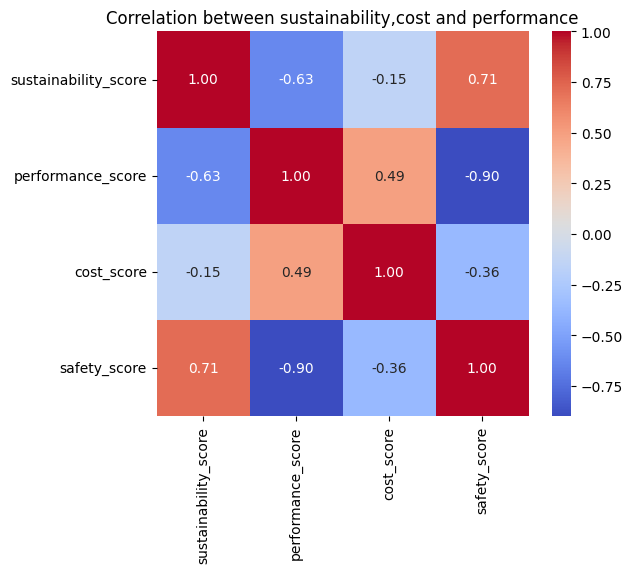

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sustainability_score','performance_score','cost_score','safety_score'

]

plt.figure(figsize=(6,5))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation between sustainability,cost and performance')
plt.show()

In [74]:
#creating the dataset for ml to train and test by giving it random nos input as prirority percentage for sustainability,cost and performance

import numpy as np
import pandas as pd

recommended = []

for i in range(0,3301):

    weights = np.random.dirichlet(np.ones(4), size=1)[0]

    wsust = weights[0]
    wpref = weights[1]
    wcost = weights[2]
    wsafety = weights[3]

    df['final_score'] = (
        wsust * df['sustainability_score']
        + wpref * df['performance_score']
        + wcost * df['cost_score']
        + wsafety * df['safety_score']
    )

    best = df.loc[df['final_score'].idxmax()]

    recommended.append(
        [
            wsust,
            wpref,
            wcost,
            wsafety,
            best['Chemistry']
        ]
    )

ml_df = pd.DataFrame(
    recommended,
    columns=[
        'sustainability_priority',
        'performance_priority',
        'cost_priority',
        'safety_priority',
        'Recommended_Chemistry'
    ]
)

print(ml_df)

      sustainability_priority  performance_priority  cost_priority  \
0                    0.444133              0.174044       0.203646   
1                    0.108729              0.225137       0.124145   
2                    0.112228              0.375512       0.139425   
3                    0.045372              0.448168       0.039826   
4                    0.194092              0.122133       0.005038   
...                       ...                   ...            ...   
3296                 0.225004              0.248573       0.523101   
3297                 0.019939              0.920158       0.010422   
3298                 0.000668              0.557845       0.199671   
3299                 0.164399              0.349373       0.318618   
3300                 0.409381              0.265117       0.150390   

      safety_priority Recommended_Chemistry  
0            0.178177                   LFP  
1            0.541989                NMC111  
2            0.372836

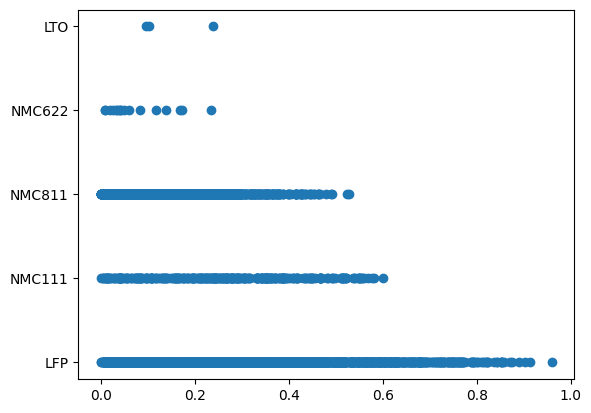

In [75]:
plt.scatter(ml_df['sustainability_priority'],ml_df['Recommended_Chemistry'])

In [76]:
print(ml_df['Recommended_Chemistry'].value_counts())

Recommended_Chemistry
LFP       1681
NMC811    1283
NMC111     317
NMC622      17
LTO          3
Name: count, dtype: int64


In [79]:
print(df.groupby('Chemistry')[
[
'sustainability_score',
'performance_score',
'cost_score',
'safety_score'
]
].mean())

           sustainability_score  performance_score  cost_score  safety_score
Chemistry                                                                   
LCO                    0.429539           0.467500    0.815129          0.85
LFP                    0.789041           0.350583    0.994458          0.95
LMO                    0.699599           0.310752    0.954332          0.94
LTO                    0.753283           0.150000    0.379382          0.97
NCA                    0.350674           0.802332    0.884203          0.82
NMC111                 0.568783           0.691917    0.915569          0.90
NMC442                 0.532977           0.612578    0.926211          0.88
NMC532                 0.493544           0.662670    0.939331          0.86
NMC622                 0.423858           0.843497    0.912736          0.84
NMC811                 0.345680           0.937652    0.905980          0.80
